# Sinú River Basin — DEM Analysis

Extracts the Sinú River basin from HydroSHEDS HydroBASINS (level 6), clips a
30m SRTM DEM to that basin, and computes elevation summary statistics.

**Inputs expected in the data folder below:**
- `dem_30.tif` — SRTM GL1 30m DEM (OpenTopography), covering the Sinú basin bounding box
- `hybas_sa_lev06_v1c.shp` — HydroBASINS South America, level 6


## 1. Setup

In [4]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import rasterio.plot
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from shapely.geometry import Point

## 2. Define paths and verify the input files exist

In [5]:
data = Path(r"C:\Users\Jhonnatan\Downloads\hybas_sa_lev01-12_v1c")

dem_path   = data / "dem_30.tif"
hybas_path = data / "hybas_sa_lev06_v1c.shp"

print(dem_path, "->", dem_path.exists())
print(hybas_path, "->", hybas_path.exists())

C:\Users\Jhonnatan\Downloads\hybas_sa_lev01-12_v1c\dem_30.tif -> True
C:\Users\Jhonnatan\Downloads\hybas_sa_lev01-12_v1c\hybas_sa_lev06_v1c.shp -> True


## 3. Load HydroBASINS and inspect

Level 6 gives basins at roughly province-sized granularity across all of South America.

In [6]:
basins = gpd.read_file(hybas_path)

print("Shape:", basins.shape)
print("CRS:  ", basins.crs)
basins.head()

Shape: (1946, 14)
CRS:   EPSG:4326


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,6060000010,0,6060000010,6060000010,0.0,0.0,4317.4,4317.4,611001,0,1,0,1,"MULTIPOLYGON (((-78.99722 9.45417, -79.00478 9..."
1,6060000200,0,6060000200,6060000200,0.0,0.0,35995.5,35996.7,611002,0,0,1,2,"POLYGON ((-77.00417 5.77083, -77.00479 5.78242..."
2,6060000210,0,6060000210,6060000210,0.0,0.0,443.9,443.9,611003,0,1,0,3,"POLYGON ((-76.8875 7.67917, -76.88971 7.67973,..."
3,6060000240,0,6060000240,6060000240,0.0,0.0,2186.3,2186.3,611004,0,0,1,4,"POLYGON ((-76.5125 7.5875, -76.50918 7.58665, ..."
4,6060000250,0,6060000250,6060000250,0.0,0.0,6533.8,6533.8,611005,0,1,0,5,"MULTIPOLYGON (((-76.17639 9.375, -76.18252 9.3..."


Quick visual check — every level-6 basin in South America:

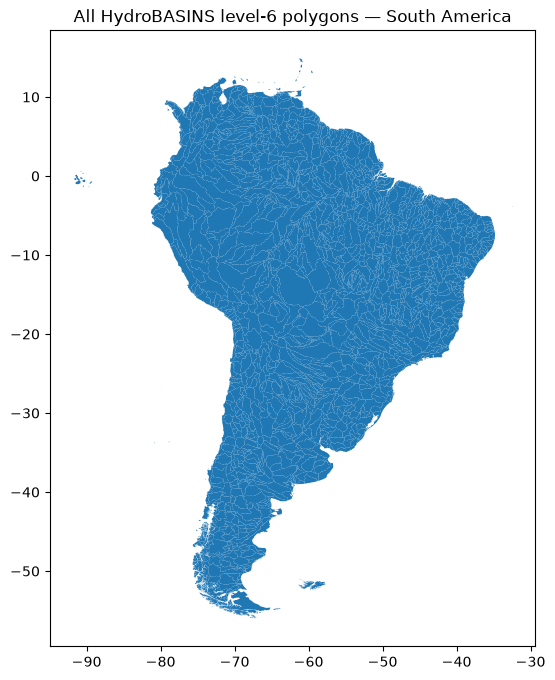

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
basins.plot(ax=ax, linewidth=0.3)
ax.set_title("All HydroBASINS level-6 polygons — South America")
plt.show()

## 4. Select the Sinú basin

HydroBASINS polygons are identified by numeric `HYBAS_ID`, not by river name,
so the basin is selected with a spatial join: a point known to fall inside the
Sinú catchment, joined against all basin polygons with `predicate="within"`.

In [8]:
point = gpd.GeoDataFrame(geometry=[Point(-75.9, 8.5)], crs="EPSG:4326")

sinu_candidate = gpd.sjoin(point, basins, predicate="within")
sinu_candidate

,geometry,index_right,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT
0,POINT (-75.9 8.5),5,6060000450,0,6060000450,6060000450,0.0,0.0,14065.1,14065.7,611006,0,0,1,6


In [9]:
sinu_id    = sinu_candidate.iloc[0]["HYBAS_ID"]
sinu_basin = basins[basins["HYBAS_ID"] == sinu_id]

print(f"HYBAS_ID: {sinu_id}")
print(f"Basin area (SUB_AREA): {sinu_basin.iloc[0]['SUB_AREA']:.1f} km2")
sinu_basin

HYBAS_ID: 6060000450
Basin area (SUB_AREA): 14065.1 km2


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
5,6060000450,0,6060000450,6060000450,0.0,0.0,14065.1,14065.7,611006,0,0,1,6,"POLYGON ((-76.02083 7.32083, -76.01841 7.32048..."


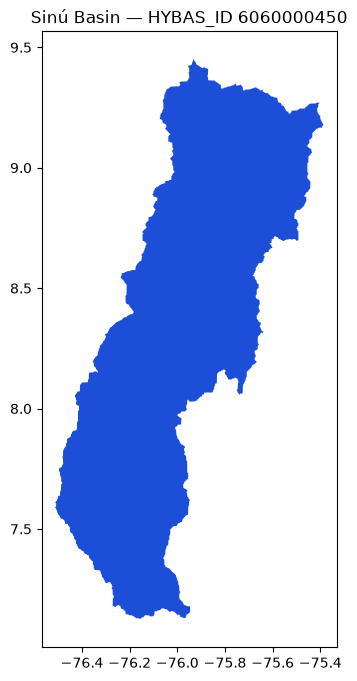

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
sinu_basin.plot(ax=ax, color="#1D4ED8")
ax.set_title(f"Sinú Basin — HYBAS_ID {sinu_id}")
plt.show()

Save the extracted basin as its own shapefile, so future notebooks don't need to repeat the spatial join:

In [11]:
sinu_basin.to_file(data / "sinu_basin.shp")

Reload and verify the saved file is correct — a cheap sanity check before moving on:

In [12]:
basin_path = data / "sinu_basin.shp"
basin = gpd.read_file(basin_path)

print("CRS:          ", basin.crs)
print("Geometry type:", basin.geometry.type.unique())
basin

CRS:           EPSG:4326
Geometry type: <StringArray>
['Polygon']
Length: 1, dtype: str


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,6060000450,0,6060000450,6060000450,0.0,0.0,14065.1,14065.7,611006,0,0,1,6,"POLYGON ((-76.02083 7.32083, -76.01841 7.32048..."


## 5. Load and inspect the DEM

In [13]:
src = rasterio.open(dem_path)

print("CRS:       ", src.crs)
print("Bounds:    ", src.bounds)
print("Resolution:", src.res)
print("Size:      ", src.width, "x", src.height)

CRS:        EPSG:4326
Bounds:     BoundingBox(left=-76.70041666669015, bottom=7.000416666678713, right=-75.25041666669047, top=9.600416666678122)
Resolution: (0.000833333333333144, 0.000833333333333144)
Size:       1740 x 3120


Overlay the basin boundary on the full DEM extent — visual confirmation that they actually overlap before clipping:

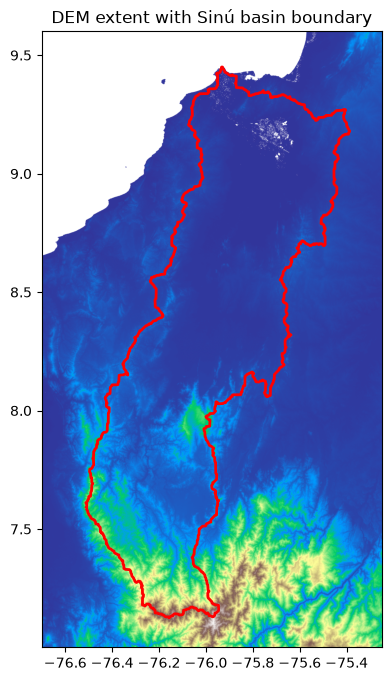

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

rasterio.plot.show(src, ax=ax, cmap="terrain")
basin.boundary.plot(ax=ax, color="red", linewidth=2)

ax.set_title("DEM extent with Sinú basin boundary")
plt.show()

## 6. Clip the DEM to the basin boundary

`rasterio.mask.mask` with `crop=True` clips the raster to the polygon's extent,
returning only the pixels inside (or touching) the basin, plus an updated
affine transform for the cropped array.

In [15]:
basin_raster = basin.to_crs(src.crs)     # ensure vector matches raster CRS
geometry     = basin_raster.geometry.values

dem_clip, transform = mask(src, geometry, crop=True)

Update the raster profile to match the new cropped dimensions and transform, then export as a standalone GeoTIFF:

In [16]:
profile = src.profile.copy()
profile.update({
    "height":    dem_clip.shape[1],
    "width":     dem_clip.shape[2],
    "transform": transform
})

output = data / "processed_dem.tif"
with rasterio.open(output, "w", **profile) as dst:
    dst.write(dem_clip)

print(f"Saved: {output}")

Saved: C:\Users\Jhonnatan\Downloads\hybas_sa_lev01-12_v1c\processed_dem.tif


## 7. Visualize the clipped DEM

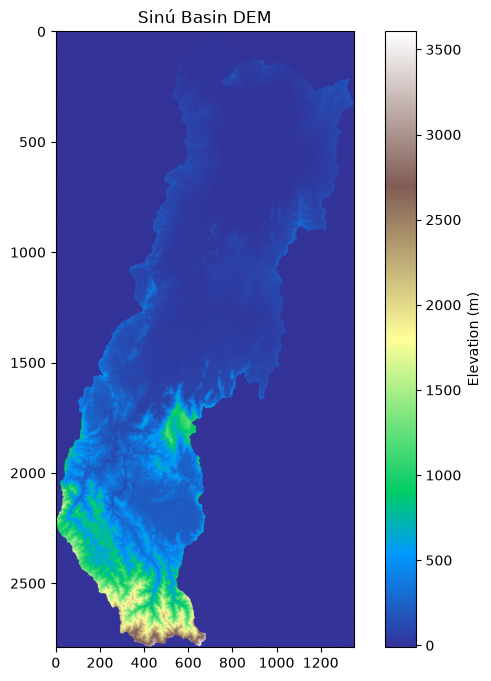

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))

im = plt.imshow(dem_clip[0], cmap="terrain")
plt.colorbar(im, label="Elevation (m)")
plt.title("Sinú Basin DEM")

plt.show()

## 8. Elevation summary statistics

`np.nan*` variants are used since clipped pixels outside the basin polygon
(within the cropped raster's bounding box) are set to NoData / NaN.

In [18]:
dem_array = dem_clip[0]

print("Min: ", np.nanmin(dem_array))
print("Max: ", np.nanmax(dem_array))
print("Mean:", np.nanmean(dem_array))
print("Std: ", np.nanstd(dem_array))

Min:  -12
Max:  3606
Mean: 117.15733478737435
Std:  318.9134010287998


In [19]:
!pip install whitebox

In [20]:
from whitebox.whitebox_tools import WhiteboxTools

In [21]:
plt.figure(figsize=(8,8))

plt.imshow(
    elevation,
    cmap="terrain"
)

plt.colorbar(
    label="Elevation (m)"
)

plt.title("Sinú Basin DEM")

plt.show()

NameError: name 'elevation' is not defined

<Figure size 800x800 with 0 Axes>

---
**Interpreting these numbers:**
- **Max** should land somewhere in the Nudo de Paramillo range (Sinú's mountainous headwaters) — a value in the 3,000–4,000 m range is expected, not an error.
- **Mean** will be pulled low by the large lowland/floodplain area relative to the smaller mountainous zone.
- **A small negative min** near the coast/river mouth is a common SRTM void-filling artifact, not real below-sea-level terrain.
- **High std relative to the mean** reflects the basin combining flat coastal lowlands with steep upstream terrain — both regimes captured in one basin polygon.
